<a href="https://colab.research.google.com/github/NatSy77/mlops_ai-projet6et8/blob/main/04_modeling_lightgbm_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initiez-vous au MLOps (partie 1/2)

## Imports et configuration

In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.5 MB/s eta 0:00:00


In [2]:
!pip install mlflow pyngrok

In [3]:
!pip install -q mlflow pyngrok

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.lightgbm
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from lightgbm import LGBMClassifier

### Config

Garder la même config que dans le notebook baseline.

In [17]:
RANDOM_STATE = 42

MLFLOW_TRACKING_URI = "file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("credit_scoring_lightgbm")

2026/04/04 08:40:20 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring_lightgbm' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/458764841029853000'), creation_time=1775292020277, experiment_id='458764841029853000', last_update_time=1775292020277, lifecycle_stage='active', name='credit_scoring_lightgbm', tags={}, workspace='default'>

In [18]:
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:///content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/mlruns


In [31]:
# Recréer ou récupérer l’expérience par son nom, pour éviter tout problème d’ID
experiment_name = "credit_scoring_lightgbm"

exp = mlflow.get_experiment_by_name(experiment_name)

if exp is None:
    experiment_id = mlflow.create_experiment(experiment_name)
    print("Nouvelle expérience créée :", experiment_id)
else:
    experiment_id = exp.experiment_id
    print("Expérience existante :", experiment_id)

mlflow.set_experiment(experiment_name)

Nouvelle expérience créée : 304992690189039647


<Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/304992690189039647'), creation_time=1775295038841, experiment_id='304992690189039647', last_update_time=1775295038841, lifecycle_stage='active', name='lightgbm_no_early_stopping', tags={}, workspace='default'>

In [20]:
exp = mlflow.get_experiment_by_name(experiment_name)
print(exp)

<Experiment: artifact_location=('file:///content/drive/MyDrive/Colab '
 'Notebooks/AI_projet_6&8/mlruns/458764841029853000'), creation_time=1775292020277, experiment_id='458764841029853000', last_update_time=1775292020277, lifecycle_stage='active', name='credit_scoring_lightgbm', tags={}, workspace='default'>


### Chargement des données

LightGBM supporte mal les colonnes object brutes dans ce contexte simple.
Pour cette version rapide, on va faire un encodage one-hot avant entraînement.

In [7]:
import os
from google.colab import drive

# Unmount Google Drive if already mounted to avoid conflicts
if os.path.exists('/content/drive'):
  print('Unmounting existing /content/drive...')
  try:
    drive.flush_and_unmount()
  except Exception as e:
    print(f'Error during unmount: {e}')

# Ensure the mount point is empty or doesn't exist
if os.path.exists('/content/drive'):
    if os.listdir('/content/drive'):
        print("Mount point '/content/drive' is not empty. Removing contents...")
        !rm -rf /content/drive/*

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Unmounting existing /content/drive...
Drive not mounted, so nothing to flush and unmount.
Mount point '/content/drive' is not empty. Removing contents...
Mounted at /content/drive


In [8]:
X = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/X_train.csv")
y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_projet_6&8/credit_scoring_data/processed/y_train.csv").values.ravel()

print(X.shape, y.shape)
print("Taux classe positive :", y.mean())

(307511, 377) (307511,)
Taux classe positive : 0.08072881945686496


### Encodage simple

In [9]:
X_encoded = pd.get_dummies(X, drop_first=False)

print("Shape après encodage :", X_encoded.shape)

Shape après encodage : (307511, 501)


In [22]:
# nettoyer les noms de colonnes juste après le get_dummies()
import re

def clean_feature_names(columns):
    cleaned = []
    seen = {}

    for col in columns:
        # convertir en string
        new_col = str(col)

        # remplacer tout caractère non alphanumérique par "_"
        new_col = re.sub(r"[^A-Za-z0-9_]+", "_", new_col)

        # éviter les multiples underscores
        new_col = re.sub(r"_+", "_", new_col)

        # retirer underscore début/fin
        new_col = new_col.strip("_")

        # si vide, donner un nom par défaut
        if new_col == "":
            new_col = "feature"

        # garantir unicité
        if new_col in seen:
            seen[new_col] += 1
            new_col = f"{new_col}_{seen[new_col]}"
        else:
            seen[new_col] = 0

        cleaned.append(new_col)

    return cleaned

X_encoded.columns = clean_feature_names(X_encoded.columns)

print("Exemple colonnes nettoyées :", X_encoded.columns[:10].tolist())

Exemple colonnes nettoyées : ['SK_ID_CURR', 'PREV_PRODUCT_COMBINATION_CASH_MEAN', 'PREV_NAME_PORTFOLIO_CARS_MEAN', 'DAYS_LAST_PHONE_CHANGE', 'PREV_NAME_GOODS_CATEGORY_MOBILE_MEAN', 'PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN', 'BURO_BB_MONTHS_BALANCE_MAX_MEAN', 'PREV_CODE_REJECT_REASON_SYSTEM_MEAN', 'PREV_NAME_TYPE_SUITE_CHILDREN_MEAN', 'PREV_AMT_DOWN_PAYMENT_MEAN']


### Split train / validation

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

### Calcul du poids de la classe positive
Pcq environ 8% de positifs, on calcule un scale_pos_weight

In [11]:
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

scale_pos_weight = n_negative / n_positive
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 11.38710976837865


### Fonctions métier et évaluation
Je reprends exactement la même logique que dans le notebook 03 baseline

In [12]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost


def business_cost_normalized(y_true, y_pred, fn_cost=10, fp_cost=1):
    return business_cost(y_true, y_pred, fn_cost, fp_cost) / len(y_true)


def evaluate_model(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    roc_auc = roc_auc_score(y_true, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    cost = business_cost_normalized(y_true, y_pred)

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "business_cost": cost
    }


def find_best_threshold(y_true, y_proba, fn_cost=10, fp_cost=1):
    thresholds = np.arange(0.01, 0.99, 0.01)

    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cost = business_cost_normalized(y_true, y_pred, fn_cost, fp_cost)
        results.append((t, cost))

    df = pd.DataFrame(results, columns=["threshold", "cost"])
    best_row = df.loc[df["cost"].idxmin()]

    return float(best_row["threshold"]), df

### Modèle LightGBM simple
Explication des paramètres :
- n_estimators=300, Nombre d’arbres construits

Plus élevé = modèle plus puissant, Mais aussi plus lent et risque d’overfitting

✔️ 200 = bon compromis pour commencer et optimiser les resources de calcul (google colab)

- learning_rate=0.05, Taille des corrections à chaque itération.

Petit learning rate = apprentissage plus progressif, Nécessite plus d’arbres

✔️ 0.05 = valeur classique et stable

- num_leaves=31, Nombre maximum de feuilles par arbre.

Contrôle la complexité du modèle, Plus grand = modèle plus flexible

✔️ 31 = valeur par défaut, bon point de départ

- max_depth=-1, Profondeur maximale des arbres.

-1 = pas de limite, laisse LightGBM gérer automatiquement

✔️ OK pour un premier modèle

- min_child_samples=20, Nombre minimum d’observations dans une feuille.

Empêche des feuilles trop petites donc réduit l’overfitting

✔️ 20 = valeur standard

- subsample=0.8, Fraction des données utilisées pour chaque arbre.

Introduit de l’aléatoire et améliore la généralisation

✔️ 0.8 = bon compromis

- colsample_bytree=0.8, Fraction des variables utilisées à chaque arbre.

réduit la corrélation entre arbres et améliore la robustesse

✔️ 0.8 recommandé

- objective="binary" Problème de classification binaire.

✔️ adapté au crédit scoring

- scale_pos_weight : PARAMÈTRE CRITIQUE dans ton cas

scale_pos_weight = nb_negatifs / nb_positifs

compense le déséquilibre des classes

Dans mon dataset :

~92% classe 0
~8% classe 1

Donc :
- sans ça → modèle biaisé vers les non-défaillants
- avec ça → meilleur recall sur les défauts


n_jobs=-1 : Utilise tous les cœurs CPU.

✔️ accélère l’entraînement

- random_state : Reproductibilité.

✔️ indispensable en MLOps

- force_col_wise=True évite juste le surcoût détecté par LightGBM

Le modèle LightGBM est configuré avec des paramètres standards permettant un bon compromis entre performance et généralisation. Le paramètre scale_pos_weight est particulièrement important dans ce contexte, car il permet de compenser le déséquilibre des classes en pénalisant davantage les erreurs sur la classe minoritaire (clients en défaut).

In [14]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    force_col_wise=True
)

### Entraînement + MLflow
** 1ere configuration***
- eval_set : dit au modèle : “évalue-toi sur le validation set”

- eval_metric="auc" : optimise sur ROC AUC

- early_stopping(50) : si aucune amélioration pendant 50 itérations → STOP

Donc :

si le modèle converge vite → il s’arrête tôt
si besoin → il va jusqu’à 200 arbres

- Pour réutiliser ce modèle plus tard, il faut aussi sauvegarder la liste finale des colonnes nettoyées:
Après l’encodage one-hot, les noms de certaines variables contenaient des caractères spéciaux non supportés par LightGBM. Une étape de normalisation des noms de colonnes a donc été ajoutée afin de garantir la compatibilité du modèle et la reproductibilité du pipeline.

Une première configuration simple de LightGBM a été testée avec prise en compte du déséquilibre des classes et mécanisme d’early stopping. Les résultats obtenus sont inférieurs à ceux de la baseline de régression logistique. Le modèle s’est arrêté très tôt (best_iteration = 1), ce qui suggère un arrêt prématuré de l’apprentissage.

**Une seconde expérimentation sans early stopping*** est donc nécessaire pour évaluer plus justement le potentiel de LightGBM.



In [24]:
import json

encoded_columns = X_encoded.columns.tolist()

with open("encoded_columns.json", "w") as f:
    json.dump(encoded_columns, f)

In [33]:
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="lightgbm_no_early_stopping"):

    model.fit(X_train, y_train)

    print("Best iteration :", model.best_iteration_)

    y_proba = model.predict_proba(X_val)[:, 1]

    best_threshold, threshold_df = find_best_threshold(y_val, y_proba)
    metrics = evaluate_model(y_val, y_proba, threshold=best_threshold)

    mlflow.log_param("model", "lightgbm")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", float(scale_pos_weight))
    mlflow.log_param("fn_cost", 10)
    mlflow.log_param("fp_cost", 1)
    mlflow.log_param("threshold", float(best_threshold))
    mlflow.log_param("n_features_input", X_train.shape[1])
    mlflow.log_param("early_stopping", False)  # important pour tracer l’expérimentation

    mlflow.log_artifact("encoded_columns.json")

    for key, value in metrics.items():
        mlflow.log_metric(key, float(value))

    mlflow.lightgbm.log_model(model, name="model")

    print("Seuil optimal :", best_threshold)
    print(metrics)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.448262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46916
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 490
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Best iteration : 0


2026/04/04 09:36:12 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Seuil optimal : 0.52
{'roc_auc': np.float64(0.7825217785241677), 'pr_auc': np.float64(0.28224924172457244), 'precision': 0.19158771829699806, 'recall': 0.6761329305135951, 'f1': 0.2985725085605016, 'business_cost': np.float64(0.4917646293676731)}


### Courbe coût vs seuil

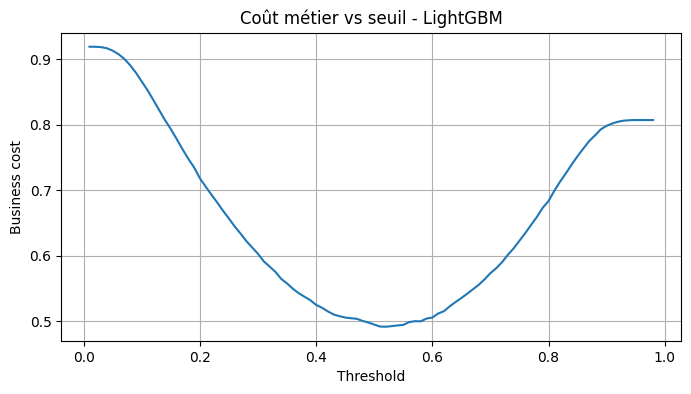

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["cost"])
plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.title("Coût métier vs seuil - lightgbm_no_early_stopping")
plt.grid(True)
plt.savefig("lgbm_cost_vs_threshold.png")
mlflow.log_artifact("lgbm_cost_vs_threshold.png")
plt.show()

### Matrice de confusion

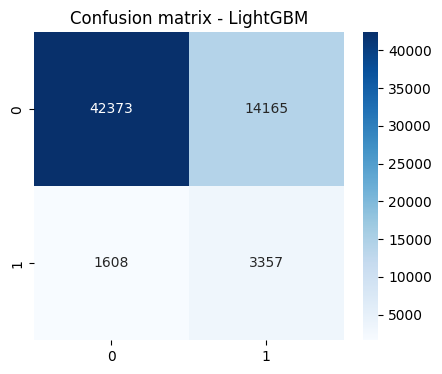

In [35]:
y_pred = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix - lightgbm_no_early_stopping")
plt.savefig("lgbm_confusion_matrix.png")
mlflow.log_artifact("lgbm_confusion_matrix.png")
plt.show()

### Feature importance

In [36]:
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances.head(20)

,feature,importance
246,EXT_SOURCE_1,227
72,EXT_SOURCE_3,195
172,EXT_SOURCE_2,193
113,AMT_CREDIT,162
251,PREV_CNT_PAYMENT_MEAN,154
19,AMT_ANNUITY,136
33,DAYS_BIRTH,133
213,AMT_GOODS_PRICE,118
140,DAYS_EMPLOYED,113
248,BURO_DAYS_CREDIT_ENDDATE_MAX,103


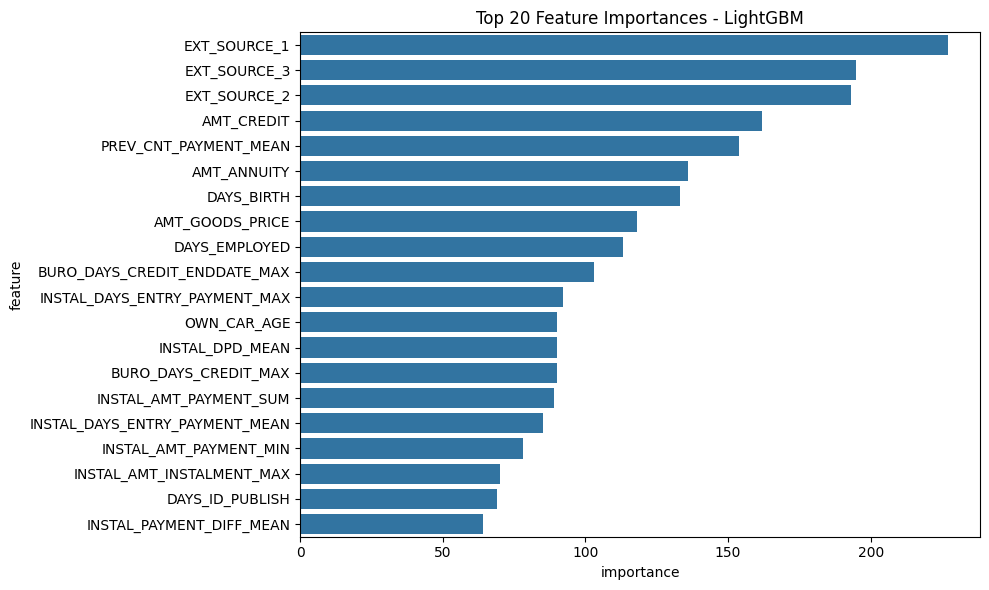

In [37]:
top_n = 20
top_features = feature_importances.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 20 Feature Importances - lightgbm_no_early_stopping")
plt.tight_layout()
plt.savefig("lgbm_feature_importance.png")
mlflow.log_artifact("lgbm_feature_importance.png")
plt.show()

### Tableau comparatif baseline vs LightGBM

In [38]:
comparison = pd.DataFrame([
    {
        "model": "logistic_regression",
        "roc_auc": 0.7684,
        "pr_auc": 0.2485,
        "precision": 0.1768,
        "recall": 0.6886,
        "f1": 0.2813,
        "business_cost": 0.5103,
        "threshold": 0.51
    },
    {
        "model": "lightgbm_no_early_stopping",
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "business_cost": metrics["business_cost"],
        "threshold": best_threshold
    }
])

comparison

,model,roc_auc,pr_auc,precision,recall,f1,business_cost,threshold
0,logistic_regression,0.768400,0.248500,0.176800,0.688600,0.281300,0.510300,0.51
1,lightgbm_simple,0.782522,0.282249,0.191588,0.676133,0.298573,0.491765,0.52


## Conclusion :
LightGBM gagne est meilleur sur tous les critères importants.

Comparaison : métrique	LogReg	lightgbm_no_early_stopping	verdict
- ROC AUC	0.7684	0.7825	✅ meilleur
- PR AUC	0.2485	0.2822	✅ beaucoup mieux
- Precision	0.1768	0.1916	✅ mieux
- Recall	0.6886	0.6761	≈ équivalent
- F1	0.2813	0.2986	✅ mieux
- Business cost	0.5103	0.4918	✅ CRITIQUE
- Threshold	0.51	0.52	cohérent

Conclusion métier :

Le coût métier est plus faible avec LightGBM, C’est LE critère principal de ton projet.

Donc :
LightGBM est le meilleur modèle

j'ai gardé un recall élevé (~0.67) → ✔️ bon pour détecter les clients à risque
J'améliores la précision → ✔️ moins de faux refus
je réduis le coût → ✔️ objectif métier atteint

Le modèle LightGBM obtient de meilleures performances que la régression logistique sur l’ensemble des métriques clés, notamment la PR AUC et le coût métier. Bien que le rappel soit légèrement inférieur, il reste élevé et permet de détecter efficacement les clients à risque. La réduction du coût métier confirme que ce modèle constitue un meilleur compromis entre performance technique et objectif business. LightGBM est donc retenu comme modèle final.